# Embeddings Exploration

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## First Embeddings

In [48]:
word1 = "Hund"
word2 = "Auto"
word3 = "Hund Hund Hund"
word4 = "Katze"
word1_emb = model.encode(word1)
word2_emb = model.encode(word2)
word3_emb = model.encode(word3)
word4_emb = model.encode(word4)

print(type(word1_emb))
print(type(word2_emb))
print(word1_emb.shape)
print(word2_emb.shape)
print(word3_emb.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(384,)
(384,)
(384,)


## Cosine Similarity

In [50]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# "Hund" und "Auto" Ähnlichkeit
word1_emb_trans = word1_emb.reshape(1,-1)
word2_emb_trans = word2_emb.reshape(1,-1)

print(cosine_similarity(word1_emb_trans, word2_emb_trans))

# "Hund" und "Hund Hund Hund" Ähnlichkeit
word3_emb_trans = word3_emb.reshape(1,-1)

print(cosine_similarity(word1_emb_trans, word3_emb_trans))

# "Hund" und "Katze" Ähnlichkeit
word4_emb_trans = word4_emb.reshape(1,-1)

print(cosine_similarity(word1_emb_trans, word4_emb_trans))

# "Auto" und "Katze" Ähnlichkeit
print(cosine_similarity(word2_emb_trans, word4_emb_trans))

[[0.1765494]]
[[0.853405]]
[[0.26022768]]
[[0.29252595]]


## More experiments

In [67]:
# Koenig - Mann + Frau ~ Koenigin?

words = ["Koenig", "Mann", "Koenigin", "Frau"]
words_emb = model.encode(words)

koenig = words_emb[0]
mann = words_emb[1]
frau = words_emb[3]

result = koenig - mann + frau
koenigin = words_emb[2]

sim_queen = cosine_similarity([result], [koenigin])[0][0]

print(f"Cosine similarity of 'King' + 'Man' - 'Women' and 'Queen':{sim_queen}")

# German English
words = ["Hund", "Dog"]
words_emb = model.encode(words)

hund = words_emb[0]
dog = words_emb[1]

sim_dogHund = cosine_similarity([hund], [dog])[0][0]

print(f"Cosine similarity of 'Hund' and 'Dog': {sim_dogHund}")

# Typing errors
words2 = ["Table", "Tabel"]
words2_emb = model.encode(words2)

table = words2_emb[0]
tabel = words2_emb[1]

sim_TableTabel = cosine_similarity([table], [tabel])[0][0]

print(f"Cosine similarity of 'Table' and 'Tabel'{sim_TableTabel}")

Cosine similarity of 'King' + 'Man' - 'Women' and 'Queen':0.5432643294334412
Cosine similarity of 'Hund' and 'Dog': 0.3353257179260254
Cosine similarity of 'Table' and 'Tabel'0.4789467751979828


## Visualization

In [13]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [4]:
words = [
    # Tiere
    "Hund", "Katze", "Vogel", "Fisch",
    # Fahrzeuge
    "Auto", "Fahrrad", "Zug", "Flugzeug",
    # Berufe
    "Arzt", "Lehrer", "Koch", "Pilot",
    # Möbel
    "Tisch", "Stuhl", "Bett", "Schrank"
]

In [26]:
words_emb = model.encode(words)
reduced = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=2).fit_transform(words_emb)
X = reduced[:,0]
y = reduced[:,1]

In [27]:
reduced

array([[ 102.8289   ,   17.475368 ],
       [  18.919994 ,   11.38261  ],
       [ -24.399313 ,  -36.152027 ],
       [   9.449047 ,   -9.244089 ],
       [-100.11817  ,   96.23919  ],
       [ -36.539295 ,   32.95351  ],
       [ -35.986015 ,  -89.907906 ],
       [ -49.286503 , -100.39164  ],
       [ -18.746782 ,  -76.84001  ],
       [ -32.02584  ,   46.072857 ],
       [ 114.698265 ,   49.475246 ],
       [ -87.08912  ,   98.64741  ],
       [  23.56768  ,  -21.574053 ],
       [  -5.5661383,  -13.234709 ],
       [  -4.44867  ,  -76.147255 ],
       [ 108.21249  ,   30.848028 ]], dtype=float32)

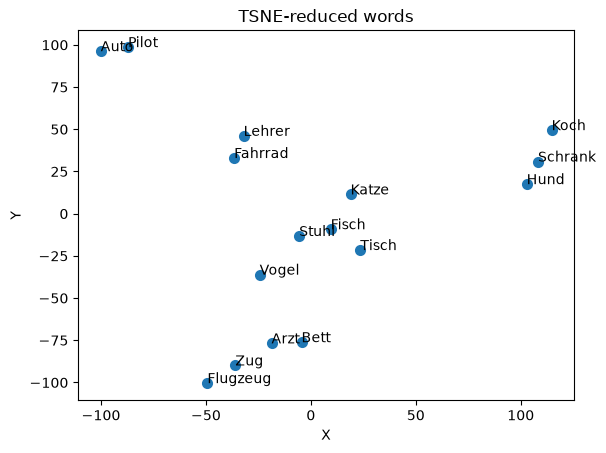

In [30]:
plt.scatter(X, y, linewidth = 2)
for i, word in enumerate(wörter):
    plt.annotate(word, (X[i], y[i]))
plt.title("TSNE-reduced words")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()